In [1]:
from MLtools import ImageData, SC_Model
from torch.utils.data import DataLoader, random_split
import torch
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_folder = "ext_data"
xml_path = "annotations.xml"

dataset = ImageData(image_folder, xml_path)
train_data, val_data = random_split(dataset, [9665, 100])

len(dataset)

9765

In [3]:
BS = 5

train_loader = DataLoader(train_data, batch_size=BS, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BS, shuffle=False)

In [4]:
def DICE(pred, target):
    smooth = 1.0
    bs = pred.size(0)
    m1 = pred.view(bs, -1)  # Flatten
    m2 = target.view(bs, -1)  # Flatten
    intersection = (m1 * m2).sum()

    return (2.0 * intersection + smooth) / (m1.sum() + m2.sum() + smooth)

def loss_SC_Model(output, target):
    BCE = torch.nn.BCELoss()
    return BCE(output, target) - 0.4*torch.log(DICE(output, target))

In [5]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = torch.load("SC_model1.pth", weights_only=False).to(device)

In [6]:
# model = SC_Model().to(device)
criterion = loss_SC_Model
print(device)

train_losses = []
val_losses   = []

cuda:0


In [7]:
# from torchsummary import summary

# summary(model, (3,640,640))


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0002)

In [9]:
n_epochs = 4

for epoch in tqdm(range(n_epochs)):
    model.train()
    train_losses_per_epoch = []
    val_losses_per_epoch   = []
    
    for batch, targets in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch.float().to(device))
        loss = criterion(outputs.view(BS, 640, 640), targets.float().to(device))
        loss.backward()
        optimizer.step()
        
        train_losses_per_epoch.append(loss.item())
    
    train_losses.append(np.mean(train_losses_per_epoch))
    train_losses_per_epoch = []
    
    model.eval()
    for batch, targets in val_loader:
        with torch.no_grad():
            outputs = model(batch.float().to(device))
            loss = criterion(outputs.view(BS, 640, 640), targets.float().to(device))
            val_losses_per_epoch.append(loss.item())
    
    val_losses.append(np.mean(val_losses_per_epoch))
    val_losses_per_epoch = []

  0%|          | 0/4 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Losses')

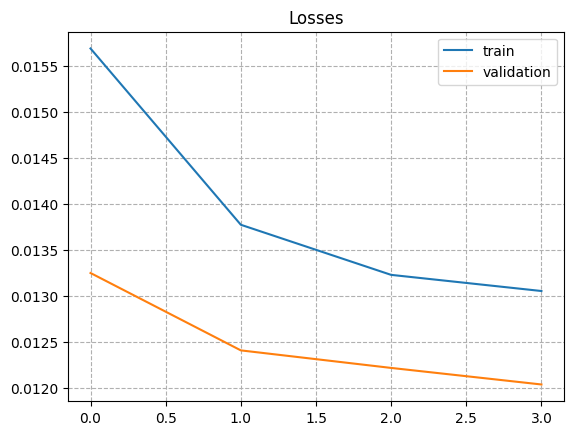

In [10]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='validation')
plt.grid(True, linestyle='--')
plt.legend()
plt.title("Losses")

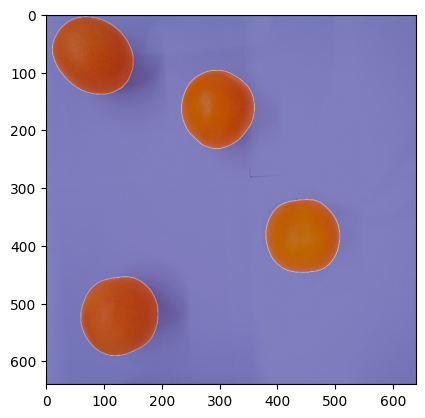

In [19]:
N = 2
with torch.no_grad():
    for batch, target in val_loader:
        output = model(batch.float().to(device))
        
        ImageData.draw_appled_mask(batch[N], output[N,0].to('cpu'), mask_koef=0.5)
        break

In [13]:
torch.save(model, "SC_model2.pth")